Ví dụ 1:

Bài tập thực hành 1:

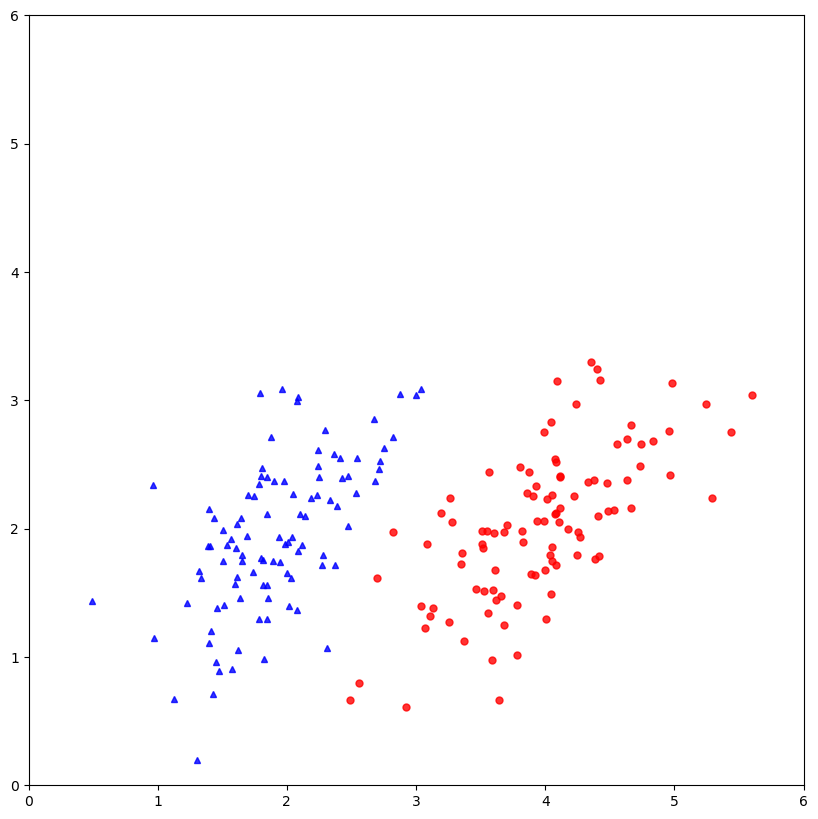

lambda = 
[[5.92924398e-10 1.94139394e-09 3.84240658e-10 2.34590064e-09
  1.99860594e-09 1.65747762e-09 1.68596002e-09 1.05828021e-09
  1.67680410e-09 2.61227214e-09 2.59068293e-09 1.20191053e-09
  1.75995285e-09 1.66696815e-09 5.06420275e-10 3.00471043e-09
  1.46994496e-09 6.59850201e-10 1.70269435e-09 1.27207328e-09
  2.02130759e-09 1.19097145e-09 8.73613571e-10 2.07801810e-10
  3.15457750e-10 1.73784338e-09 1.18126342e-09 1.81094794e-09
  9.80210835e-10 2.84478869e-10 1.33542342e-09 1.24303751e-09
  1.80395436e-08 1.43745324e-09 1.62392389e-09 1.83974875e-09
  2.53966002e-10 1.70564370e-09 1.92398711e-09 3.08485833e-10
  1.60412081e-09 1.73669606e-09 2.64262343e-10 1.73952420e-09
  2.42376933e-09 3.57114903e+01 1.27412787e-09 1.42277650e-09
  1.48918195e-09 2.16249949e-09 2.08678373e-09 1.77004934e-09
  1.34113039e-09 1.85409124e-09 2.14778316e-09 1.53106273e-09
  1.64051465e-09 4.32408561e-10 1.53457308e-09 8.23766279e-10
  1.83555412e-09 1.79358082e-09 3.13552818e-09 3.45283742e-1

In [1]:
from __future__ import print_function 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.spatial.distance import cdist 
np.random.seed(22) 
means = [[2, 2], [4, 2]] 
cov = [[.3, .2], [.2, .3]] 
N = 100
X0 = np.random.multivariate_normal(means[0], cov, N) # class 1 
X1 = np.random.multivariate_normal(means[1], cov, N) # class -1 
X = np.concatenate((X0.T, X1.T), axis = 1) # all data 
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1) # labels 

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10)) 
ani = plt.cla() 
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8) 
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8) 
ani = plt.axis([0 , 6, 0, 6]) 
plt.show() 

from cvxopt import matrix, solvers 
# build K 
V = np.concatenate((X0.T, -X1.T), axis = 1) 
K = matrix(V.T.dot(V)) # see definition of V, K near eq (??) 
p = matrix(-np.ones((2*N, 1))) # all-one vector 
# build A, b, G, h 

G = matrix(-np.eye(2*N)) # for all lambda_n >= 0! note that we solve -g(lambda) -> min 
h = matrix(np.zeros((2*N, 1))) 
A = matrix(y) # the equality constrain is actually y^T lambda = 0 
b = matrix(np.zeros((1, 1))) 
solvers.options['show_progress'] = False 
sol = solvers.qp(K, p, G, h, A, b) 
l = np.array(sol['x']) # lambda
print('lambda = ') 
print(l.T)

epsilon = 1e-6 # just a small number, greater than 1e-9, to filter values of lambda 
S = np.where(l > epsilon)[0] 
VS = V[:, S] 
XS = X[:, S] 
yS = y[:, S] 
lS = l[S] 
# calculate w and b 
w = VS.dot(lS) 
b = np.mean(yS.T - w.T.dot(XS)) 
print('w = ', w.T) 
print('b = ', b)
print("-------------------------------")
from sklearn.svm import SVC 
# Copy and put code for generate data here
y1 = y.reshape((2*N,)) 
X1 = X.T # each sample is one row 
clf = SVC(kernel = 'linear', C = 1e5) # just a big number 
# if C is small, method will be “SoftMagin SVM”, 
# if C is large enough, method is near to hard margin
clf.fit(X1, y1) 
w = clf.coef_ 
w0 = clf.intercept_ 
print('w = ', w) 
print('b = ', w0)

y_pred = clf.predict(X1)
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy = ', accuracy_score(y1, y_pred))
print('Confusion matrix =', str(confusion_matrix(y1, y_pred)))

Bài thực hành 2:

In [45]:
from sklearn import datasets
 
cancer_data = datasets.load_breast_cancer()
# show to test record 5th
print(cancer_data.data[5])
print(cancer_data.data.shape)
#target set
print(cancer_data.target)
from sklearn.model_selection import train_test_split
 
cancer_data = datasets.load_breast_cancer()
 
X_train, X_test, y_train, y_test = train_test_split(cancer_data.data, cancer_data.target, test_size=0.3,random_state=109) 
from sklearn.svm import SVC 

# Khởi tạo mô hình SVM
model = SVC(kernel='linear', C=1e5)
# Huấn luyện mô hình trên tập huấn luyện
model.fit(X_train, y_train)
w = model.coef_ 
w0 = model.intercept_ 
print('w = ', w) 
print('b = ', w0)
# Đánh giá mô hình trên tập kiểm tra
print("Accuracy:", model.score(X_test, y_test))

y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
print('Confusion matrix =', str(confusion_matrix(y_test, y_pred)))

[1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]
(569, 30)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 

Ví dụ 2:

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("D:\Code\Python\MachineLearning\Week_9\sonar.all-data.csv", header = None)
data.iloc[:,-1] = data.iloc[:,-1].apply(lambda x: 1 if x=='M' else -1)

X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.svm import SVC 

# Khởi tạo mô hình SVM
model = SVC(kernel='linear', C=1e5)
# Huấn luyện mô hình trên tập huấn luyện
model.fit(X_train, y_train)

# Đánh giá mô hình trên tập kiểm tra
print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.8333333333333334


C:\Users\ACER\AppData\Local\Temp\ipykernel_2508\3955114955.py:5: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:,-1] = data.iloc[:,-1].apply(lambda x: 1 if x=='M' else -1)
